In [1]:
import torch
import torchvision
from torch import nn
from torchvision import transforms

from aif import Classifier, DataModule, Trainer, show_images

In [2]:
class FashionMNIST(DataModule):
    def __init__(self, root='../data/', batch_size=64, resize=(28, 28), num_workers=2):
        super().__init__(root, batch_size)
        
        self.num_workers = num_workers

        transform = transforms.Compose([
            transforms.Resize(resize),
            transforms.ToTensor()
        ])

        self.train = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=True,
            download=True,
            transform=transform
        )

        self.val = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=False,
            download=True,
            transform=transform
        )

    def text_labels(self, indices):
        labels = [
            't-shirt', 'trouser', 'pullover', 'dress', 'coat',
            'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
        ]

        return [labels[int(i)] for i in indices]

    def get_dataloader(self, train):
        data = self.train if train else self.val

        return torch.utils.data.DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=train,
            num_workers=self.num_workers
        )
    
    def visualize(self, batch, nrows=1, ncols=8, labels=None):
        X, y = batch
        if labels is None:
            labels = self.text_labels(y)
        show_images(X, nrows, ncols, titles=labels)

In [3]:
class SoftmaxClassifierScratch(Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__(lr)
        
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

        self.W = nn.Parameter(torch.normal(0, sigma, size=(num_inputs, num_outputs)))
        self.b = nn.Parameter(torch.zeros(num_outputs))

    def softmax(self, X):
        X = X - X.amax(1, keepdim=True)
        X_exp = torch.exp(X)
        partition = torch.sum(X_exp, 1, keepdim=True)
        
        return X_exp / partition
    
    def forward(self, X):
        X = X.reshape((X.shape[0], -1))
        
        return self.softmax((X @ self.W) + self.b)

    def loss(self, y_hat, y):
        return -torch.log(
            y_hat[torch.arange(len(y_hat)), y]
        ).mean()

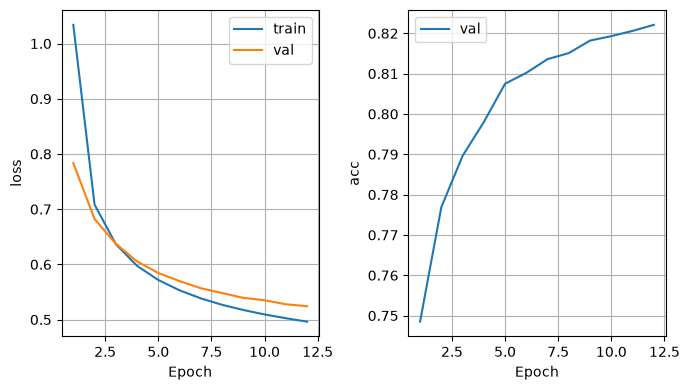

Epoch 12/12 | train_loss: 0.496306 | val_loss: 0.524255 | val_acc: 0.822100


In [4]:
data = FashionMNIST(batch_size=256)

model = SoftmaxClassifierScratch(num_inputs=784, num_outputs=10, lr=0.03)

trainer = Trainer(max_epochs=12)
trainer.fit(model, data)

In [5]:
X, y = next(iter(data.val_dataloader()))

with torch.no_grad():
    y_hat = model(X)

In [6]:
preds = y_hat.argmax(1)

wrong = preds != y

wrong.type(torch.int).sum() / len(preds)

tensor(0.1602)

In [7]:
right = preds == y

right.type(torch.int).sum() / len(preds)

tensor(0.8398)

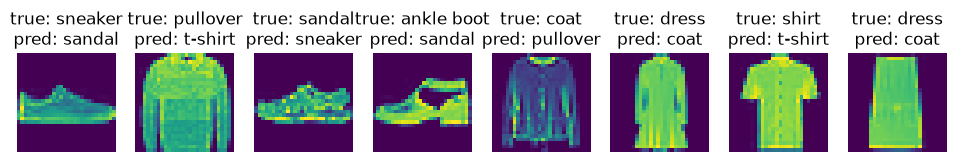

In [8]:
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [
    f'true: {a}\npred: {b}'
    for a,b in zip(data.text_labels(y), data.text_labels(preds))
]

data.visualize([X, y], labels=labels)

In [9]:
class SoftmaxClassifier(Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__(lr)

        linear = nn.Linear(num_inputs, num_outputs)

        linear.weight.data.normal_(0, sigma)
        linear.bias.data.fill_(0)
        
        self.net = nn.Sequential(
            nn.Flatten(),
            linear
        )

        self.num_outputs = num_outputs

    def forward(self, X):
        return self.net(X)

    def loss(self, Y_hat, Y, averaged=True):
        # reshaped to support multi-dimensional predictions & targets
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        Y = Y.reshape(-1)
        
        return nn.functional.cross_entropy(
            Y_hat, Y, reduction='mean' if averaged else 'none'
        )

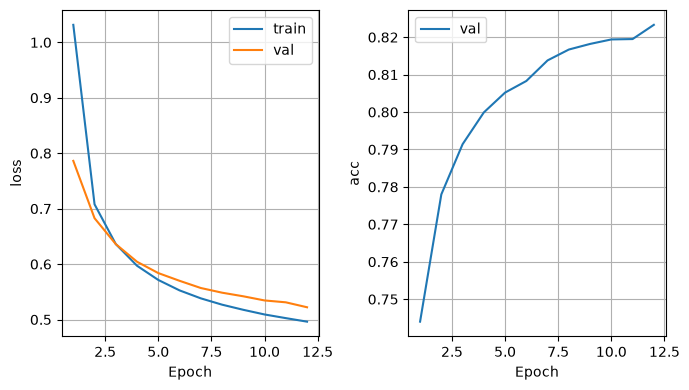

Epoch 12/12 | train_loss: 0.496199 | val_loss: 0.522152 | val_acc: 0.823300


In [10]:
model = SoftmaxClassifier(num_inputs=784, num_outputs=10, lr=0.03)

trainer = Trainer(max_epochs=12)
trainer.fit(model, data)

In [11]:
X, y = next(iter(data.val_dataloader()))

with torch.no_grad():
    y_hat = model(X)

In [12]:
preds = y_hat.argmax(1)

wrong = preds != y

wrong.type(torch.int).sum() / len(preds)

tensor(0.1602)

In [13]:
right = preds == y

right.type(torch.int).sum() / len(preds)

tensor(0.8398)

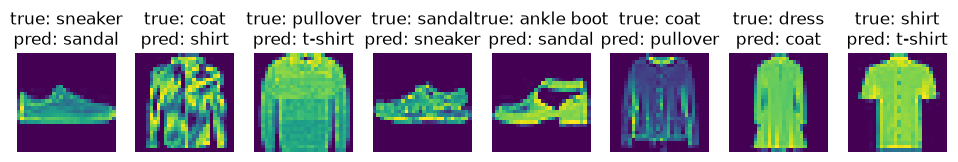

In [14]:
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [
    f'true: {a}\npred: {b}'
    for a,b in zip(data.text_labels(y), data.text_labels(preds))
]

data.visualize([X, y], labels=labels)